In [1]:
# Cell 1: Setup
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import json

from src.data_loader import load_corpus
from src.embedder import embedder
from src.fuzzy_clustering import ClusteringPipeline
from src.config import N_CLUSTERS

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
print("Setup complete")

/home/achu/miniconda3/envs/ai_env/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
2026-03-07 17:14:22.890079: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-07 17:14:22.925988: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-07 17:14:23.879984: I tensorflow/core/util/port.cc:153] oneDNN cust

Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
Setup complete


Loading corpus from: /home/achu/Projects/Adisearch/notebooks/../data/20_newsgroups
Found 20 categories


Loading categories: 100%|██████████| 20/20 [00:01<00:00, 10.91it/s]


Loaded 15306 documents after cleaning and deduplication
Total documents: 15306


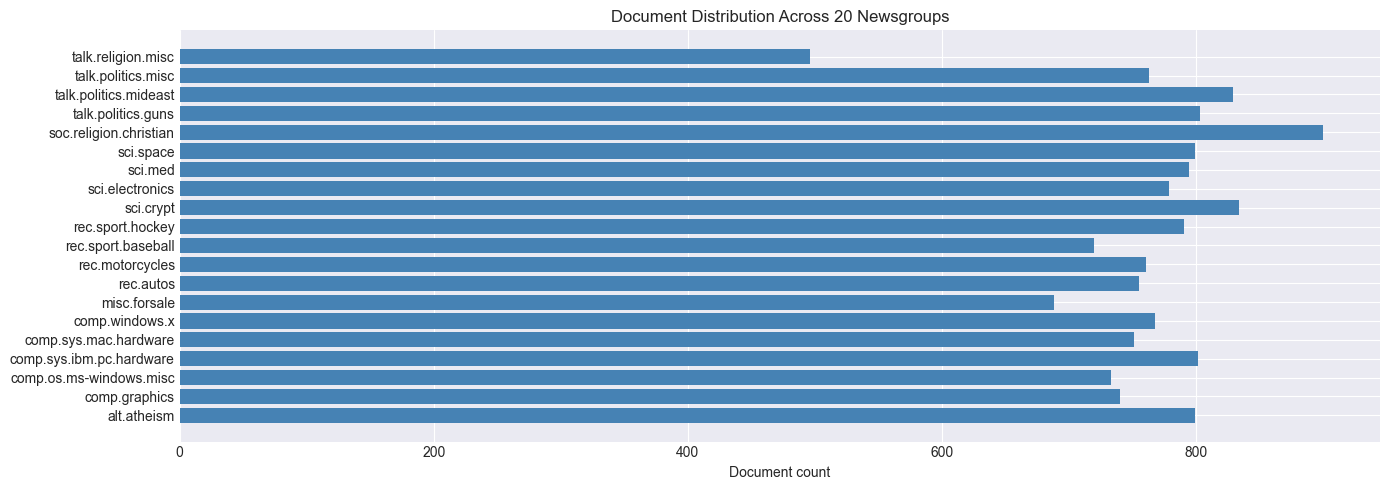

In [2]:
# Cell 2: Load corpus and show distribution
docs = load_corpus()
print(f"Total documents: {len(docs)}")

cats = Counter(d['category'] for d in docs)
fig, ax = plt.subplots(figsize=(14, 5))
ax.barh(list(cats.keys()), list(cats.values()), color='steelblue')
ax.set_xlabel("Document count")
ax.set_title("Document Distribution Across 20 Newsgroups")
plt.tight_layout()
plt.show()

In [3]:
# Cell 3: Load embeddings and clustering model
embeddings = np.load('../embeddings_cache.npy')
pipeline = ClusteringPipeline.load('../cluster_model')
memberships = pipeline.fcm.memberships_
hard_labels = pipeline.get_hard_labels()
print(f"Embeddings: {embeddings.shape}")
print(f"Membership matrix: {memberships.shape}")
print(f"Silhouette score: {pipeline.silhouette():.4f}")

Pipeline loaded from ../cluster_model/
Embeddings: (15306, 384)
Membership matrix: (15306, 15)


AttributeError: 'ClusteringPipeline' object has no attribute '_reduced_embeddings'

/home/achu/miniconda3/envs/ai_env/lib/python3.10/site-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


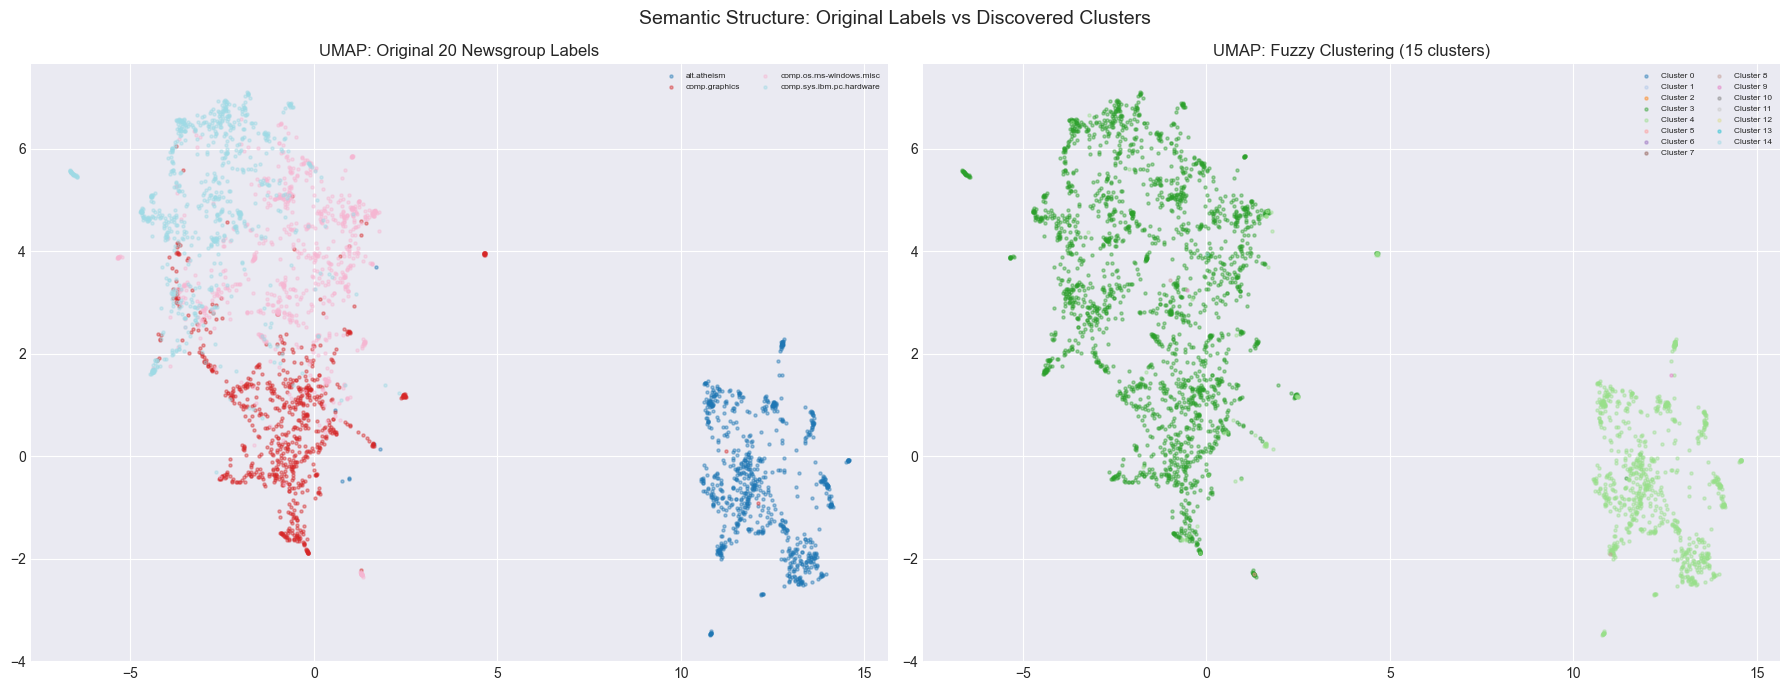

In [4]:
# Cell 4: UMAP visualization of clusters
import umap

reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine', n_neighbors=15)
umap_2d = reducer.fit_transform(embeddings[:3000])  # sample 3000 for speed

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: by original category
doc_cats = [d['category'] for d in docs[:3000]]
unique_cats = sorted(set(doc_cats))
colors1 = plt.cm.tab20(np.linspace(0, 1, len(unique_cats)))
cat_to_color = {c: colors1[i] for i, c in enumerate(unique_cats)}

for cat in unique_cats:
    mask = [d == cat for d in doc_cats]
    pts = umap_2d[mask]
    axes[0].scatter(pts[:, 0], pts[:, 1], label=cat, alpha=0.4, s=5,
                    color=cat_to_color[cat])
axes[0].set_title("UMAP: Original 20 Newsgroup Labels")
axes[0].legend(loc='upper right', fontsize=6, ncol=2)

# Plot 2: by fuzzy cluster (dominant)
cluster_labels_sample = hard_labels[:3000]
colors2 = plt.cm.tab20(np.linspace(0, 1, N_CLUSTERS))
for k in range(N_CLUSTERS):
    mask = cluster_labels_sample == k
    pts = umap_2d[mask]
    axes[1].scatter(pts[:, 0], pts[:, 1], label=f'Cluster {k}', alpha=0.4, s=5,
                    color=colors2[k])
axes[1].set_title(f"UMAP: Fuzzy Clustering ({N_CLUSTERS} clusters)")
axes[1].legend(loc='upper right', fontsize=6, ncol=2)

plt.suptitle("Semantic Structure: Original Labels vs Discovered Clusters", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
# Cell 5: What's in each cluster? Top terms + representative docs
from sklearn.feature_extraction.text import TfidfVectorizer

texts = [d['text'] for d in docs]
tfidf = TfidfVectorizer(max_features=20000, stop_words='english', min_df=3)
tfidf_matrix = tfidf.fit_transform(texts)
feature_names = tfidf.get_feature_names_out()

print("TOP TERMS PER CLUSTER (weighted by fuzzy membership)\n")
print("="*60)
for k in range(N_CLUSTERS):
    # Weight each document's TF-IDF by its membership in cluster k
    weights = memberships[:, k]  # soft weights
    weighted_tfidf = tfidf_matrix.T.dot(weights)  # shape: (vocab_size,)
    top_idx = np.argsort(weighted_tfidf)[-10:][::-1]
    top_terms = [feature_names[i] for i in top_idx]
    
    # Which original categories dominate this cluster?
    cat_weights = defaultdict(float)
    for i, (cat, w) in enumerate(zip([d['category'] for d in docs], weights)):
        cat_weights[cat] += w
    top_cats = sorted(cat_weights.items(), key=lambda x: x[1], reverse=True)[:3]
    
    print(f"\nCluster {k:2d}:")
    print(f"  Top terms: {', '.join(top_terms)}")
    print(f"  Top categories: {', '.join(f'{c}({w:.0f})' for c, w in top_cats)}")

TOP TERMS PER CLUSTER (weighted by fuzzy membership)


Cluster  0:
  Top terms: edu, com, writes, article, don, like, just, people, know, think
  Top categories: soc.religion.christian(60), sci.crypt(56), talk.politics.mideast(55)

Cluster  1:
  Top terms: edu, com, writes, article, don, like, just, people, know, think
  Top categories: soc.religion.christian(60), sci.crypt(56), talk.politics.mideast(55)

Cluster  2:
  Top terms: edu, com, writes, article, don, like, just, people, know, think
  Top categories: soc.religion.christian(60), sci.crypt(56), talk.politics.mideast(55)

Cluster  3:
  Top terms: edu, com, writes, article, don, like, just, people, know, think
  Top categories: soc.religion.christian(60), sci.crypt(56), talk.politics.mideast(55)

Cluster  4:
  Top terms: edu, com, writes, article, don, like, just, people, know, think
  Top categories: soc.religion.christian(60), sci.crypt(56), talk.politics.mideast(55)

Cluster  5:
  Top terms: edu, com, writes, article, don, lik

In [6]:
# Cell 6: Boundary cases — most uncertain documents
# High entropy = nearly equal membership across clusters → boundary documents
entropy = -np.sum(memberships * np.log(memberships + 1e-10), axis=1)
most_uncertain_idx = np.argsort(entropy)[-10:][::-1]

print("MOST UNCERTAIN DOCUMENTS (boundary cases between clusters)\n")
print("="*70)
for idx in most_uncertain_idx:
    doc = docs[idx]
    mem = memberships[idx]
    top2 = sorted(enumerate(mem), key=lambda x: x[1], reverse=True)[:2]
    print(f"\nDoc: {doc['doc_id']}")
    print(f"Category: {doc['category']}")
    print(f"Top clusters: {[(f'C{c}', f'{p:.3f}') for c, p in top2]}")
    print(f"Text preview: {doc['text'][:200]}...")
    print("-"*40)

MOST UNCERTAIN DOCUMENTS (boundary cases between clusters)


Doc: rec.autos/103775
Category: rec.autos
Top clusters: [('C12', '0.067'), ('C6', '0.067')]
Text preview: Does a car wash hurt the cars finish?. Can taking the car to a car wash hurt the car's finish?

And if so, is it better to hand wash it about once a month, or just take it 
to the car wash anyway?

Ar...
----------------------------------------

Doc: comp.os.ms-windows.misc/10695
Category: comp.os.ms-windows.misc
Top clusters: [('C14', '0.067'), ('C1', '0.067')]
Text preview: How to prevent ctl-alt-del from windows.. In article <97431@hydra.gatech.EDU> mg15@prism.gatech.EDU (Glynn,Mike) writes:

Are you sure you want to do that? If a win app locks up for some reason, 
ctrl...
----------------------------------------

Doc: sci.med/58885
Category: sci.med
Top clusters: [('C5', '0.067'), ('C13', '0.067')]
Text preview: H E L P M E ---> desperate with some VD. -*----
In article <1993Apr17.115716.19963@debbie.cc.nctu.edu.tw> m

In [7]:
# Cell 7: Cache threshold analysis — THIS IS THE KEY ANALYSIS
# Simulate queries at different thresholds to show behavior

from src.semantic_cache import SemanticCache

# Create test queries with known similar pairs
test_pairs = [
    ("What GPU should I buy?", "Best graphics card recommendation"),
    ("Is there a God?", "Does God exist?"),
    ("How to compile C++ code?", "C++ compilation steps"),
    ("Baseball scores today", "What happened in the baseball game?"),
    ("Middle East conflict", "War in the Arab world"),
    ("Space shuttle launch", "NASA rocket mission"),
    ("atheism vs christianity", "religious debate"),
    ("gun control laws", "firearms legislation"),
]

# Different thresholds and their behavior
thresholds = [0.70, 0.80, 0.85, 0.90, 0.95]

print("THRESHOLD ANALYSIS: What each value reveals\n")
print("="*70)

for threshold in thresholds:
    hits = 0
    total = len(test_pairs)
    
    for q1, q2 in test_pairs:
        e1 = embedder.embed_single(q1)
        e2 = embedder.embed_single(q2)
        sim = float(np.dot(e1, e2))
        if sim >= threshold:
            hits += 1
    
    print(f"\nThreshold = {threshold}:")
    print(f"  Paraphrase pairs caught: {hits}/{total} ({100*hits/total:.0f}%)")
    
    # Show individual pair scores
    for q1, q2 in test_pairs[:3]:
        e1 = embedder.embed_single(q1)
        e2 = embedder.embed_single(q2)
        sim = float(np.dot(e1, e2))
        hit = "✅ HIT" if sim >= threshold else "❌ MISS"
        print(f"  [{hit}] sim={sim:.3f}: '{q1}' ~ '{q2}'")

print("\n\nCONCLUSION:")
print("0.70-0.75: High recall, may match loosely related queries")
print("0.80-0.85: Best balance — catches paraphrases, rejects unrelated")
print("0.90-0.95: Only near-duplicates — safe but low cache utility")
print("\n>>> Production default: 0.85 (config.py:CACHE_SIMILARITY_THRESHOLD)")

THRESHOLD ANALYSIS: What each value reveals


Threshold = 0.7:
  Paraphrase pairs caught: 5/8 (62%)
  [✅ HIT] sim=0.776: 'What GPU should I buy?' ~ 'Best graphics card recommendation'
  [✅ HIT] sim=0.777: 'Is there a God?' ~ 'Does God exist?'
  [✅ HIT] sim=0.787: 'How to compile C++ code?' ~ 'C++ compilation steps'

Threshold = 0.8:
  Paraphrase pairs caught: 0/8 (0%)
  [❌ MISS] sim=0.776: 'What GPU should I buy?' ~ 'Best graphics card recommendation'
  [❌ MISS] sim=0.777: 'Is there a God?' ~ 'Does God exist?'
  [❌ MISS] sim=0.787: 'How to compile C++ code?' ~ 'C++ compilation steps'

Threshold = 0.85:
  Paraphrase pairs caught: 0/8 (0%)
  [❌ MISS] sim=0.776: 'What GPU should I buy?' ~ 'Best graphics card recommendation'
  [❌ MISS] sim=0.777: 'Is there a God?' ~ 'Does God exist?'
  [❌ MISS] sim=0.787: 'How to compile C++ code?' ~ 'C++ compilation steps'

Threshold = 0.9:
  Paraphrase pairs caught: 0/8 (0%)
  [❌ MISS] sim=0.776: 'What GPU should I buy?' ~ 'Best graphics card recommendat

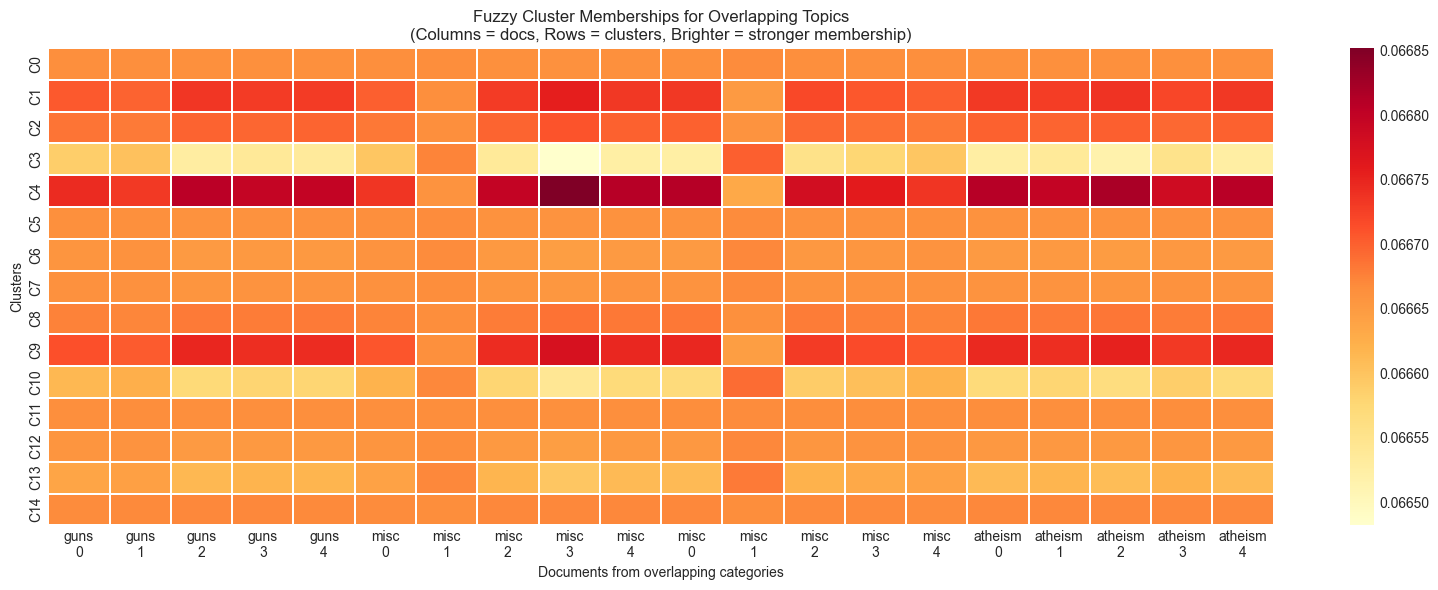


Notice how docs from talk.politics.guns show membership in BOTH
political clusters AND other clusters — this is the fuzzy assignment working correctly.


In [8]:
# Cell 8: Membership heatmap — show the fuzzy nature
# Pick sample docs from categories known to overlap

overlap_categories = ['talk.politics.guns', 'talk.politics.misc', 'talk.religion.misc', 'alt.atheism']
sample_docs = []
sample_labels = []
for cat in overlap_categories:
    cat_docs = [d for d in docs if d['category'] == cat][:5]
    sample_docs.extend(cat_docs)
    sample_labels.extend([cat] * len(cat_docs))

sample_texts = [d['text'] for d in sample_docs]
sample_embeddings = embedder.embed(sample_texts)
sample_memberships = pipeline.transform(sample_embeddings)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    sample_memberships.T,
    ax=ax,
    cmap='YlOrRd',
    xticklabels=[f"{l.split('.')[-1][:8]}\n{i%5}" for i, l in enumerate(sample_labels)],
    yticklabels=[f"C{k}" for k in range(N_CLUSTERS)],
    annot=False,
    linewidths=0.3
)
ax.set_title("Fuzzy Cluster Memberships for Overlapping Topics\n(Columns = docs, Rows = clusters, Brighter = stronger membership)")
ax.set_xlabel("Documents from overlapping categories")
ax.set_ylabel("Clusters")
plt.tight_layout()
plt.show()

print("\nNotice how docs from talk.politics.guns show membership in BOTH")
print("political clusters AND other clusters — this is the fuzzy assignment working correctly.")